# 97. BL Baseline — 시총 상위 N개 유니버스

98/99_baseline과 동일한 구조이나 **매월 시총 상위 TOP_N개만** 유니버스로 사용.

| 항목 | 98_baseline | 99_baseline | **97_TopN** |
|------|------------|-------------|-------------|
| TRAIN_WINDOW | 24개월 | 60개월 | **60개월** |
| 예측 시작 | 2006-01 | 2009-01 | **2009-01** |
| 유니버스 | 전체 (~400개) | 전체 (~400개) | **시총 상위 N개** |
| T/N (N=50) | 0.06 | 0.15 | **1.2** |
| LW 권장 T/N | — | — | >2 권장, >1 허용 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '97_TopN_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TOP_N        = 50    # 시총 상위 N개 (50, 100, 150 등 변경 가능)
TRAIN_WINDOW = 60     # 60개월
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2009-01-01'
Q_FIXED      = 0.003  # 월 0.3% = 연 3.6%
LAM_FIXED    = 2.5    # None이면 SPY 기반 동적 계산, 숫자면 고정 (He & Litterman 1999)

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'TOP_N = {TOP_N}  |  T/N = {TRAIN_WINDOW}/{TOP_N} = {TRAIN_WINDOW/TOP_N:.2f}')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')
print(f'LAM_FIXED = {LAM_FIXED}  (None이면 동적 계산)')

패널: (108180, 11)
예측 기간: 2009-01-31 ~ 2025-12-31 (204개월)
TOP_N = 50  |  T/N = 60/50 = 1.20
Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)
LAM_FIXED = 2.5  (None이면 동적 계산)


In [2]:
# ── BL 함수 ──────────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)

def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    if LAM_FIXED is not None:
        lam = LAM_FIXED
    else:
        lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
        lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam

def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P

def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)

def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)

def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)

print('BL 함수 정의 완료')

BL 함수 정의 완료


In [3]:
# ── Walk-forward (구성 진단 로깅 포함) ────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
composition_log = []
print(f'Walk-forward (TOP_{TOP_N}): {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < TOP_N:
            continue

        # ── 시총 상위 TOP_N 필터링 ──────────────────────────────
        mcap_all = np.exp(month_df['log_mcap'])
        top_tix  = mcap_all.nlargest(TOP_N).index.tolist()
        month_df = month_df.reindex(top_tix).dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 10:
            continue

        universe = month_df.index.tolist()
        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 10:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)

        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P     = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, Q_FIXED, omega, TAU)

        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)

        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})

        # ── 구성 진단 로깅 ─────────────────────────────────────
        n_group       = max(1, int(len(valid_tix) * PCT_GROUP))
        sorted_by_vol = month_df['vol_21d'].sort_values()
        low_risk_tix  = sorted_by_vol.index[:n_group].tolist()
        high_risk_tix = sorted_by_vol.index[-n_group:].tolist()
        vol           = month_df['vol_21d']

        composition_log.append({
            'date'            : pred_date,
            'n_stocks'        : len(valid_tix),
            'bl_eff_n'        : 1.0 / float((w_bl**2).sum()),
            'bl_hhi'          : float((w_bl**2).sum()),
            'bl_top10_share'  : float(w_bl.nlargest(10).sum()),
            'bl_avg_vol'      : float((w_bl * vol).sum()),
            'bl_low_weight'   : float(w_bl[low_risk_tix].sum()),
            'bl_high_weight'  : float(w_bl[high_risk_tix].sum()),
            'bl_top1_weight'  : float(w_bl.max()),
            'bl_top1_ticker'  : w_bl.idxmax(),
            'capm_eff_n'      : 1.0 / float((w_capm**2).sum()),
            'capm_top10_share': float(w_capm.nlargest(10).sum()),
            'capm_avg_vol'    : float((w_capm * vol).sum()),
            'capm_low_weight' : float(w_capm[low_risk_tix].sum()),
            'capm_high_weight': float(w_capm[high_risk_tix].sum()),
        })

    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')

bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
comp     = pd.DataFrame(composition_log).set_index('date')
comp.to_csv(DATA_DIR / f'portfolio_composition_top{TOP_N}.csv')
print('완료')

Walk-forward (TOP_50): 2009-01-31 ~ 2025-12-31
  2009-12-31 (12/204)
  2010-12-31 (24/204)
  2011-12-31 (36/204)
  2012-12-31 (48/204)
  2013-12-31 (60/204)
  2014-12-31 (72/204)
  2015-12-31 (84/204)
  2016-12-31 (96/204)
  2017-12-31 (108/204)
  2018-12-31 (120/204)
  2019-12-31 (132/204)
  2020-12-31 (144/204)
  2021-12-31 (156/204)
  2022-12-31 (168/204)
  2023-12-31 (180/204)
  2024-12-31 (192/204)
  2025-12-31 (204/204)

성공: 204개월 / 204개월
에러: 0개월
완료


In [4]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN        = np.sqrt(12)
rf_monthly = rf_series.reindex(bl_ret.index).fillna(0)

def performance(ret, rf, label):
    excess  = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    print(f'[{label}]')
    print(f'  연환산 수익률: {ann_ret:.2%}')
    print(f'  연환산 변동성: {ann_vol:.2%}')
    print(f'  Sharpe Ratio:  {sharpe:.3f}')
    print(f'  누적 수익률:   {cum_ret:.2%}')
    print(f'  MDD:           {mdd:.2%}')
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

print('=' * 55)
print(f'포트폴리오 성과 비교 — TOP_{TOP_N} 유니버스')
print(f'기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')
print('=' * 55)
stats = []
for ret, label in [(bl_ret,'BL (Top50)'), (capm_ret,'CAPM 균형'), (spy_ret,'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교 — TOP_50 유니버스
기간: 2009-01-31 ~ 2025-12-31
[BL (Top50)]
  연환산 수익률: 15.44%
  연환산 변동성: 12.36%
  Sharpe Ratio:  1.144
  누적 수익률:   1094.32%
  MDD:           -15.51%

[CAPM 균형]
  연환산 수익률: 16.16%
  연환산 변동성: 16.21%
  Sharpe Ratio:  0.918
  누적 수익률:   1125.77%
  MDD:           -23.61%

[S&P 500]
  연환산 수익률: 15.46%
  연환산 변동성: 14.72%
  Sharpe Ratio:  0.964
  누적 수익률:   nan%
  MDD:           -23.93%



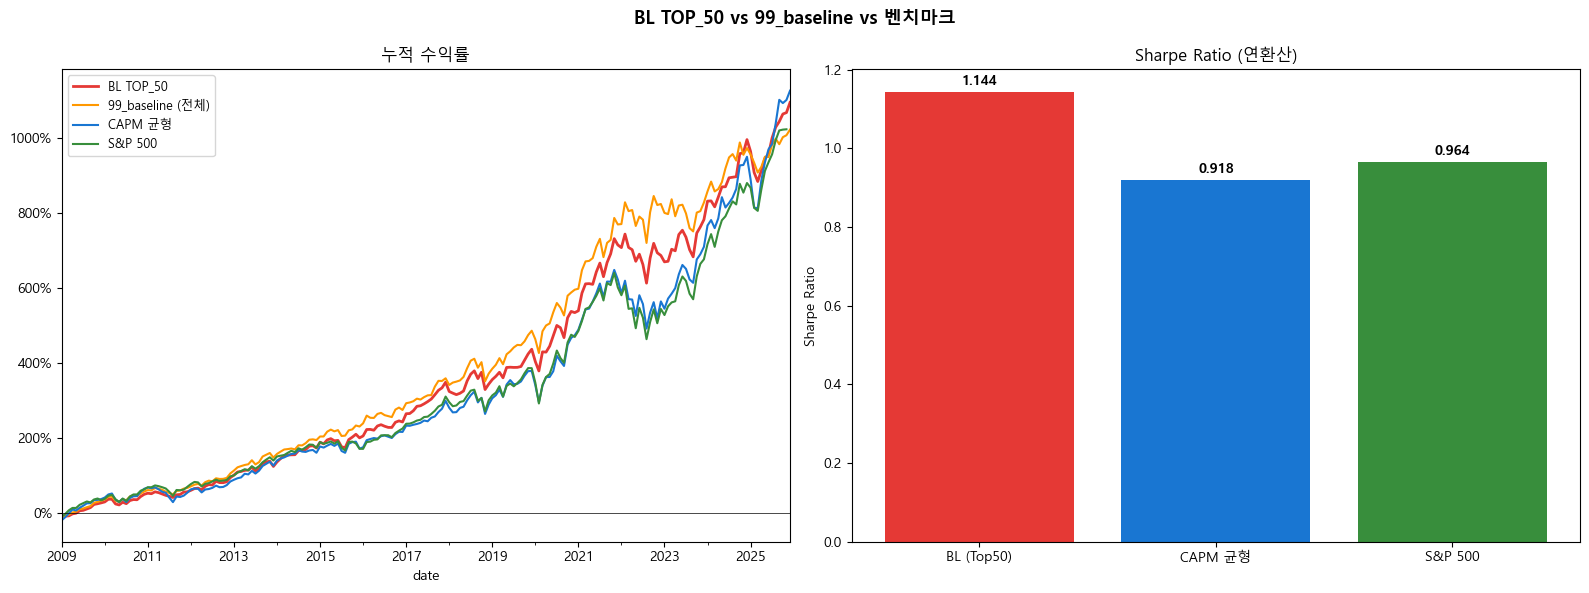

저장 완료


In [5]:
# ── 99_baseline 결과와 비교 ───────────────────────────────────
BASELINE_PATH = DATA_DIR / 'bl_baseline_returns.csv'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BL TOP_{TOP_N} vs 99_baseline vs 벤치마크', fontsize=13, fontweight='bold')

ax = axes[0]
lines = [
    (bl_ret,   f'BL TOP_{TOP_N}', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',       '#1976D2', 1.5),
    (spy_ret,  'S&P 500',         '#388E3C', 1.5),
]

# 99_baseline 결과 오버레이 (파일 있을 때만)
if BASELINE_PATH.exists():
    bl99 = pd.read_csv(BASELINE_PATH, index_col='date', parse_dates=True)['bl']
    bl99 = bl99.reindex(bl_ret.index)
    lines.insert(1, (bl99, '99_baseline (전체)', '#FF9800', 1.5))

for ret, label, color, lw in lines:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)

ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / f'bl_top{TOP_N}_performance.png', dpi=150, bbox_inches='tight')
plt.show()

result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / f'bl_top{TOP_N}_returns.csv')
print('저장 완료')

Prior 비교 — TOP_50 유니버스

[BL TOP_50 (시총가중 prior)]
  Sharpe: 1.144  연수익: 15.44%  변동성: 12.36%  MDD: -15.51%

[BL TOP_50 (1/N prior)    ]
  Sharpe: 1.138  연수익: 15.18%  변동성: 12.18%  MDD: -14.53%

[단순 저변동성 (BL 없음)        ]
  Sharpe: 1.033  연수익: 14.15%  변동성: 12.42%  MDD: -17.69%

[S&P 500                        ]
  Sharpe: 0.964  연수익: 15.46%  변동성: 14.72%  MDD: -23.93%


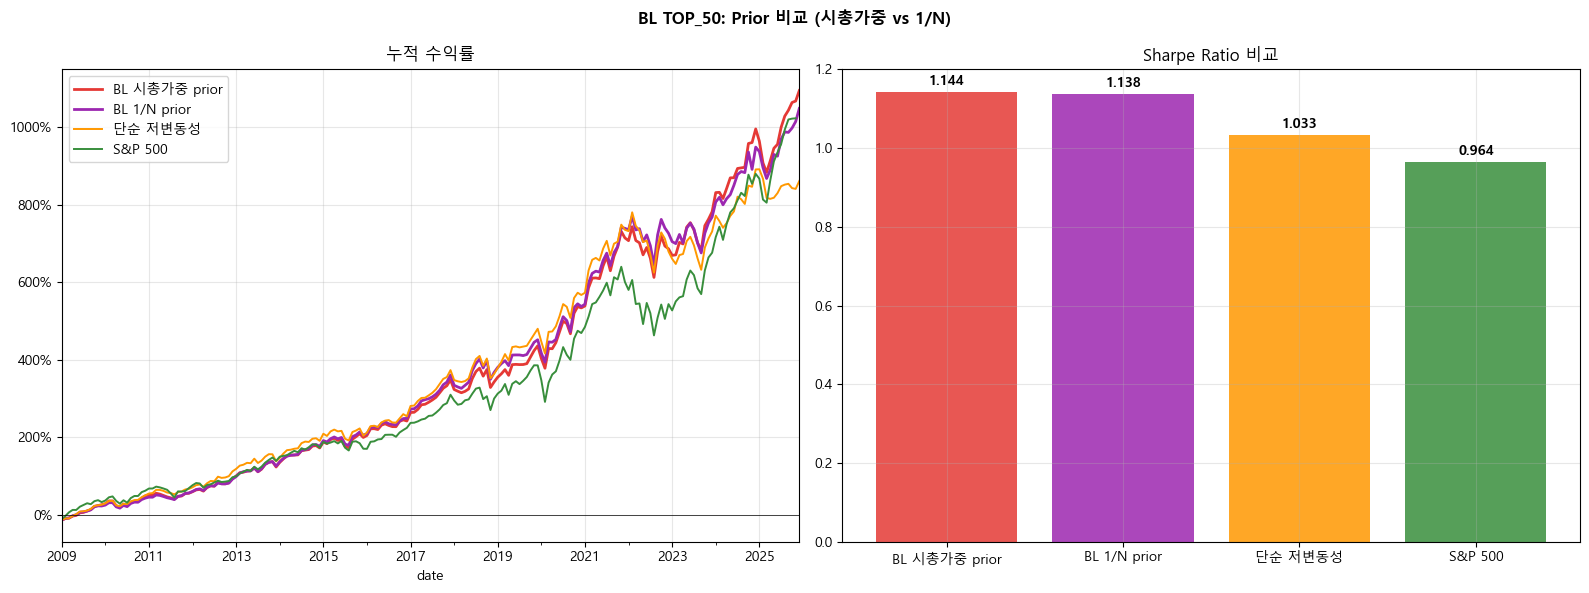

In [6]:
# ── Prior: 1/N (동일가중) vs 시총가중 + 단순 저변동성 비교 ────
rf_m = rf_series.reindex(bl_ret.index).fillna(0)

# 단순 저변동성 (TOP_N 유니버스 내, BL 없음)
naive_returns = []
for pred_date in pred_dates:
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'fwd_ret_1m'])
        if len(month_df) < TOP_N:
            continue
        mcap_all = np.exp(month_df['log_mcap'])
        top_tix  = mcap_all.nlargest(TOP_N).index.tolist()
        month_df = month_df.reindex(top_tix).dropna(
            subset=['vol_21d', 'log_mcap', 'fwd_ret_1m'])
        if len(month_df) < 10:
            continue
        n_group  = max(1, int(len(month_df) * PCT_GROUP))
        low_tix  = month_df['vol_21d'].sort_values().index[:n_group]
        mcap_low = np.exp(month_df.loc[low_tix, 'log_mcap'])
        w_naive  = mcap_low / mcap_low.sum()
        naive_returns.append({'date': pred_date,
                              'ret': float(w_naive @ month_df.loc[low_tix, 'fwd_ret_1m'].fillna(0))})
    except:
        pass
naive_ret = pd.DataFrame(naive_returns).set_index('date')['ret']

# 1/N prior BL (TOP_N 유니버스)
bl_eq_returns = []
for pred_date in pred_dates:
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < TOP_N:
            continue
        mcap_all = np.exp(month_df['log_mcap'])
        top_tix  = mcap_all.nlargest(TOP_N).index.tolist()
        month_df = month_df.reindex(top_tix).dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 10:
            continue
        universe    = month_df.index.tolist()
        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        thresh      = int(len(train_dates) * 0.7)
        ret_slice   = (ret_pivot.reindex(index=train_dates, columns=universe)
                                .dropna(axis=1, thresh=thresh).fillna(0))
        valid_tix   = ret_slice.columns.tolist()
        if len(valid_tix) < 10:
            continue
        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        w_eq       = pd.Series(1.0 / len(valid_tix), index=valid_tix)
        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()
        pi_eq, lam = compute_pi(Sigma, w_eq, spy_excess, sigma2_mkt)
        mcap       = np.exp(month_df['log_mcap'])
        P          = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        mu_BL_eq   = black_litterman(pi_eq, Sigma, P, Q_FIXED, omega, TAU)
        w_bl_eq    = optimize_portfolio(mu_BL_eq, Sigma, lam)
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        bl_eq_returns.append({'date': pred_date, 'ret': float(w_bl_eq @ actual_ret)})
    except:
        pass
bl_eq_ret = pd.DataFrame(bl_eq_returns).set_index('date')['ret']

# ── 성과 출력 ─────────────────────────────────────────────────
print('=' * 60)
print(f'Prior 비교 — TOP_{TOP_N} 유니버스')
print('=' * 60)
for ret, label in [
    (bl_ret,    f'BL TOP_{TOP_N} (시총가중 prior)'),
    (bl_eq_ret, f'BL TOP_{TOP_N} (1/N prior)    '),
    (naive_ret,  '단순 저변동성 (BL 없음)        '),
    (spy_ret,    'S&P 500                        '),
]:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    sr  = exc.mean() / exc.std() * np.sqrt(12)
    ar  = ret.mean() * 12
    av  = ret.std() * np.sqrt(12)
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'\n[{label}]')
    print(f'  Sharpe: {sr:.3f}  연수익: {ar:.2%}  변동성: {av:.2%}  MDD: {mdd:.2%}')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BL TOP_{TOP_N}: Prior 비교 (시총가중 vs 1/N)', fontweight='bold')

portfolios_p = [
    (bl_ret,    'BL 시총가중 prior', '#E53935', 2.0),
    (bl_eq_ret, 'BL 1/N prior',      '#9C27B0', 2.0),
    (naive_ret, '단순 저변동성',     '#FF9800', 1.4),
    (spy_ret,   'S&P 500',           '#388E3C', 1.4),
]
ax = axes[0]
for ret, label, color, lw in portfolios_p:
    (1 + ret).cumprod().sub(1).plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(); ax.axhline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3)

ax = axes[1]
lbs, srs, cls = [], [], []
for ret, label, color, lw in portfolios_p:
    rf  = rf_m.reindex(ret.index).fillna(0)
    exc = ret - rf
    lbs.append(label)
    srs.append(exc.mean() / exc.std() * np.sqrt(12))
    cls.append(color)
bars = ax.bar(lbs, srs, color=cls, alpha=0.85)
for bar, val in zip(bars, srs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio 비교')
ax.axhline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / f'bl_top{TOP_N}_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()